In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("pizza_sales.csv")
df.head()


,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (48620, 12)


In [5]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  str    
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  str    
 5   order_time         48620 non-null  str    
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  str    
 9   pizza_category     48620 non-null  str    
 10  pizza_ingredients  48620 non-null  str    
 11  pizza_name         48620 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 4.5 MB


In [7]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


In [8]:
df.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
for col in df.columns:
    print(col, ":", df[col].nunique())


pizza_id : 48620
order_id : 21350
pizza_name_id : 91
quantity : 4
order_date : 358
order_time : 16382
unit_price : 25
total_price : 56
pizza_size : 5
pizza_category : 4
pizza_ingredients : 32
pizza_name : 32


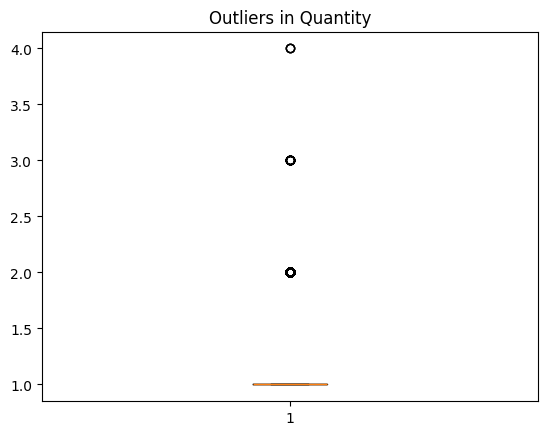

In [11]:
df["quantity"].value_counts()

plt.boxplot(df["quantity"])
plt.title("Outliers in Quantity")
plt.show()


In [14]:
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True)

print("First order:", df["order_date"].min())
print("Last order:", df["order_date"].max())

daily_orders = df.groupby("order_date")["order_id"].nunique()

daily_orders.head()


First order: 2015-01-01 00:00:00
Last order: 2015-12-31 00:00:00


order_date
2015-01-01    69
2015-01-02    67
2015-01-03    66
2015-01-04    52
2015-01-05    54
Name: order_id, dtype: int64

In [17]:
df["order_time"] = pd.to_datetime(df["order_time"], format="%H:%M:%S")

df["hour"] = df["order_time"].dt.hour

df["hour"].value_counts().sort_index()


hour
9        4
10      17
11    2672
12    6543
13    6203
14    3521
15    3170
16    4185
17    5143
18    5359
19    4350
20    3487
21    2528
22    1370
23      68
Name: count, dtype: int64

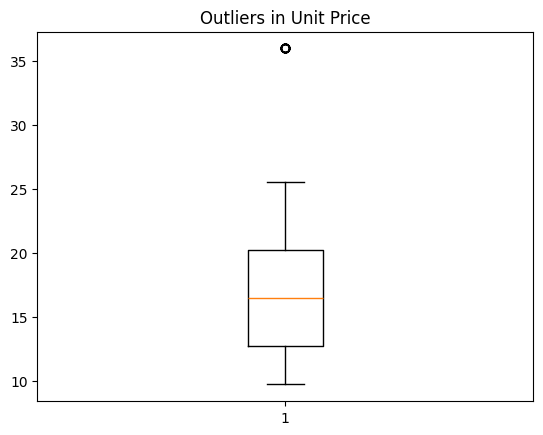

In [18]:
df["unit_price"].describe()

plt.boxplot(df["unit_price"])
plt.title("Outliers in Unit Price")
plt.show()


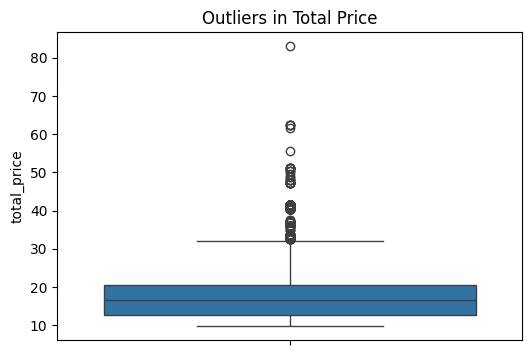

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["total_price"])

plt.title("Outliers in Total Price")
plt.show()

In [21]:
df["pizza_size"].value_counts()

pizza_size
L      18526
M      15385
S      14137
XL       544
XXL       28
Name: count, dtype: int64

In [22]:
df["pizza_category"].value_counts()

pizza_category
Classic    14579
Supreme    11777
Veggie     11449
Chicken    10815
Name: count, dtype: int64

In [23]:
df["pizza_ingredients"].head()

0             Sliced Ham, Pineapple, Mozzarella Cheese
1    Pepperoni, Mushrooms, Red Onions, Red Peppers,...
2    Mozzarella Cheese, Provolone Cheese, Smoked Go...
3    Calabrese Salami, Capocollo, Tomatoes, Red Oni...
4    Tomatoes, Red Peppers, Jalapeno Peppers, Red O...
Name: pizza_ingredients, dtype: str

In [24]:
df["pizza_name"].value_counts().head(10)

pizza_name
The Classic Deluxe Pizza        2416
The Barbecue Chicken Pizza      2372
The Hawaiian Pizza              2370
The Pepperoni Pizza             2369
The Thai Chicken Pizza          2315
The California Chicken Pizza    2302
The Spicy Italian Pizza         1887
The Sicilian Pizza              1887
The Southwest Chicken Pizza     1885
The Four Cheese Pizza           1850
Name: count, dtype: int64

In [25]:
df["total_price"].sum()

df.groupby("pizza_category")["total_price"].sum()


pizza_category
Chicken    195919.50
Classic    220053.10
Supreme    208197.00
Veggie     193690.45
Name: total_price, dtype: float64

In [26]:
df["quantity"].sum()

df.groupby("pizza_name")["quantity"].sum().sort_values(ascending=False).head(10)


pizza_name
The Classic Deluxe Pizza        2453
The Barbecue Chicken Pizza      2432
The Hawaiian Pizza              2422
The Pepperoni Pizza             2418
The Thai Chicken Pizza          2371
The California Chicken Pizza    2370
The Sicilian Pizza              1938
The Spicy Italian Pizza         1924
The Southwest Chicken Pizza     1917
The Big Meat Pizza              1914
Name: quantity, dtype: int64

In [27]:
df.groupby("pizza_size")["quantity"].sum()

pizza_size
L      18956
M      15635
S      14403
XL       552
XXL       28
Name: quantity, dtype: int64